Bad value in file WindowsPath('C:/Users/chensong/.matplotlib/stylelib/my_current_style.mplstyle'), line 128 ('grid.color : #b0b0b0'): Key grid.color: '' does not look like a color arg


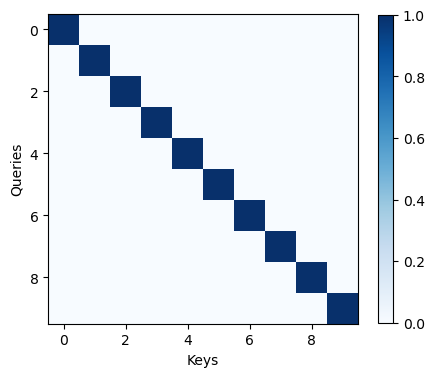

In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

# Function to visualize attention heatmaps
def show_heatmaps(matrices, xlabel, ylabel, titles=None, 
                  figsize=(5, 5), cmap='Blues'):
    """Show heatmaps of matrices."""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, 
                             figsize=figsize, sharex=True, 
                             sharey=True, squeeze=False)
    for i in range(num_rows):
        for j in range(num_cols):
            ax = axes[i, j]
            matrix_np = matrices[i, j].detach().cpu().numpy()
            pcm = ax.imshow(matrix_np, cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                if j < len(titles):
                    ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes.ravel().tolist(), shrink=0.8)
    plt.show()

# Represents weights where query 'i' attends strongly only to key 'i'
# Shape: (batch_size, num_heads, num_queries, num_keys)
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys',
              ylabel='Queries')

In [2]:
import torch
from torch import nn

def masked_softmax(X, valid_lens):
    # X: 3D tensor (batch_size, num_queries, num_keys)
    # valid_lens: 1D or 2D tensor specifying valid lengths for keys
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            # Expand to 2D: (batch_size, num_queries)
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            # Ensure valid_lens is 2D: (batch_size, num_queries)
             valid_lens = valid_lens.reshape(-1) # Flatten first if needed
             # This assumes the total number of elements matches batch_size * num_queries
             if valid_lens.numel() != shape[0] * shape[1]:
                 # If it doesn't match, perhaps valid_lens applies per batch item, not per query
                 # Replicate per query for each batch item
                 valid_lens = torch.repeat_interleave(valid_lens, shape[1], dim=0).reshape(-1)
             else: # Already (batch_size * num_queries)
                 pass # Keep as is


        # Reshape X for masking: (batch_size * num_queries, num_keys)
        X_reshaped = X.reshape(-1, shape[-1])

        # Create mask: (batch_size * num_queries, num_keys)
        # Compare sequence indices with valid lengths
        mask = torch.arange(shape[-1], dtype=torch.float32,
                            device=X.device)[None, :] < valid_lens[:, None]

        # Apply mask: set masked elements to a large negative value
        X_reshaped[~mask] = -1e6
        return nn.functional.softmax(X_reshaped.reshape(shape), dim=-1)

print("Masked Softmax Example:")
x = torch.rand(2, 2, 4)
valid_lens1 = torch.tensor([2, 3])
valid_lens2 = torch.tensor([[1, 3], [2, 4]])
print(masked_softmax(torch.rand(2, 2, 4), valid_lens1))
print(masked_softmax(torch.rand(2, 2, 4), valid_lens2))

Masked Softmax Example:
tensor([[[0.7258, 0.2742, 0.0000, 0.0000],
         [0.5959, 0.4041, 0.0000, 0.0000]],

        [[0.3098, 0.4035, 0.2867, 0.0000],
         [0.2357, 0.3421, 0.4221, 0.0000]]])
tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3500, 0.2332, 0.4169, 0.0000]],

        [[0.3759, 0.6241, 0.0000, 0.0000],
         [0.2192, 0.3295, 0.1962, 0.2551]]])


In [3]:
class AdditiveAttention(nn.Module):
    """Additive attention."""
    def __init__(self, key_size, query_size, num_hiddens, 
                 dropout):
        super().__init__()
        # Linear layer for q, k, v
        self.W_k = nn.Linear(key_size, num_hiddens, 
                             bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, 
                             bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        # Project queries and keys
        proj_queries = self.W_q(queries)
        proj_keys = self.W_k(keys)
        # Additive attention score calculation
        features = torch.tanh(
            proj_queries.unsqueeze(2) + proj_keys.unsqueeze(1)
        )
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        o = torch.bmm(self.dropout(self.attention_weights), values)
        return o

batch_size, num_queries, num_kv, query_dim, key_dim, value_dim = 2, 1, 10, 20, 2, 4
queries = torch.randn(batch_size, num_queries, query_dim)
keys = torch.randn(batch_size, num_kv, key_dim)
values = torch.randn(batch_size, num_kv, value_dim)
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=key_dim, query_size=query_dim,
                              num_hiddens=8, dropout=0.1)
output = attention(queries, keys, values, valid_lens)
print("Output Shape:", output.shape)
print("Weights Shape:", attention.attention_weights.shape)

Output Shape: torch.Size([2, 1, 4])
Weights Shape: torch.Size([2, 1, 10])


In [4]:
import math
class DotProductAttention(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Calculate scaled scores using batch matrix multiplication
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)

        # Get attention weights using masked softmax
        self.attention_weights = masked_softmax(scores, valid_lens)

        # Compute weighted average of values
        return torch.bmm(self.dropout(self.attention_weights), values)

queries_dot = torch.normal(0, 1, (2, 1, 2)) # (batch, num_queries, dim)
keys_dot = torch.normal(0, 1, (2, 10, 2))  # (batch, num_keys, dim)
values_dot = torch.normal(0, 1, (2, 10, 4)) # (batch, num_keys, value_dim)
valid_lens_dot = torch.tensor([2, 6])

attention_dot = DotProductAttention(dropout=0.0)
output_dot = attention_dot(queries_dot, keys_dot, values_dot, valid_lens_dot)
print("\nScaled Dot-Product Attention Example:")
print("Output Shape:", output_dot.shape)
print("Weights Shape:", attention_dot.attention_weights.shape)


Scaled Dot-Product Attention Example:
Output Shape: torch.Size([2, 1, 4])
Weights Shape: torch.Size([2, 1, 10])


In [5]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention."""
    def __init__(self, num_hiddens, num_heads, dropout=0.0, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        # Scaled dot-product attention per head
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)

    def _transpose_qkv(self, X):
        """Prepare tensor for parallel head computation."""
        # Input: (batch_size, num_items, num_hiddens)
        # Output: (batch_size * num_heads, num_items, num_hiddens_per_head)
        batch_size, num_items, _ = X.shape
        num_hiddens_per_head = self.W_q.out_features // self.num_heads
        X = X.reshape(batch_size, num_items, self.num_heads, num_hiddens_per_head)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, num_items, num_hiddens_per_head)

    def _transpose_output(self, X):
        """Reverse the transposition to concatenate heads."""
        # Input: (batch_size * num_heads, num_queries, num_hiddens_per_head)
        num_queries = X.shape[1]
        num_hiddens_per_head = X.shape[2]
        X = X.reshape(-1, self.num_heads, num_queries, num_hiddens_per_head)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], num_queries, -1)

    def forward(self, queries, keys, values, valid_lens):
        # Project Q, K, V for all heads at once
        proj_queries = self.W_q(queries)
        proj_keys = self.W_k(keys)
        proj_values = self.W_v(values)

        # Transpose for parallel attention
        queries_trans = self._transpose_qkv(proj_queries)
        keys_trans = self._transpose_qkv(proj_keys)
        values_trans = self._transpose_qkv(proj_values)

        # Adapt valid_lens for the new batch dimension (batch_size * num_heads)
        if valid_lens is not None:
             # Assumes valid_lens is 1D (batch_size,) applying to keys/values
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)

        # Compute attention in parallel for all heads
        output = self.attention(queries_trans, keys_trans, values_trans, valid_lens)

        # Concatenate results from heads
        output_concat = self._transpose_output(output)

        # Final linear projection
        return self.W_o(output_concat)

# Example Usage for Multi-Head Attention
num_hiddens, num_heads = 100, 5
attention_multi = MultiHeadAttention(num_hiddens, num_heads, dropout=0.5)

batch_size, num_queries, num_kvpairs = 2, 4, 6
queries_multi = torch.ones((batch_size, num_queries, num_hiddens))
keys_multi = torch.ones((batch_size, num_kvpairs, num_hiddens))
values_multi = torch.ones((batch_size, num_kvpairs, num_hiddens))
valid_lens_multi = torch.tensor([3, 2]) # (batch_size,)

output_multi = attention_multi(queries_multi, keys_multi, values_multi, valid_lens_multi)
print("Output Shape:", output_multi.shape)

Output Shape: torch.Size([2, 4, 100])


e:\conda_envs\SSL-RT\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [6]:
num_hiddens, num_heads = 100, 5
batch_size, seq_length = 2, 50 
input_dim = num_hiddens

# Create a self-attention layer
self_attention = MultiHeadAttention(num_hiddens, num_heads)

# input tensor X (batch_size, seq_length, dimension)
X = torch.rand((batch_size, seq_length, input_dim))
valid_lens = torch.tensor([seq_length, seq_length - 10])
# Pass X as queries, keys, and values
output_self = self_attention(X, X, X, valid_lens)

print("Input Shape (X):", X.shape)
print("Output Shape:", output_self.shape)

Input Shape (X): torch.Size([2, 50, 100])
Output Shape: torch.Size([2, 50, 100])


Positional Encoding Matrix P shape: torch.Size([1, 60, 32])


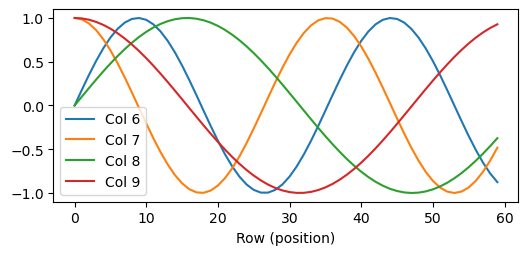

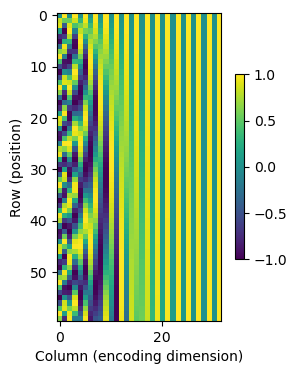

In [7]:
import torch
from torch import nn
import matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    """Positional encoding."""
    def __init__(self, num_hiddens, dropout=0.0, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # Create a sufficiently long positional encoding matrix P
        self.P = torch.zeros((1, max_len, num_hiddens)) # Shape: (1, max_len, d)

        # Calculate the positional encoding matrix P
        # Position tensor (i): shape (max_len, 1)
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        # Denominator term: 10000^(2j/d)
        div_term = torch.pow(10000, torch.arange(0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)

        # Calculate sine for even indices (2j)
        self.P[0, :, 0::2] = torch.sin(position / div_term)
        # Calculate cosine for odd indices (2j+1)
        self.P[0, :, 1::2] = torch.cos(position / div_term)

    def forward(self, X):
        # Add positional encoding P up to the sequence length of X
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)


def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(5, 5), cmap='viridis'):
    """Show heatmaps of matrices."""
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                             sharex=True, sharey=True, squeeze=False)
    for i, row_axes in enumerate(axes):
        for j, ax in enumerate(row_axes):
            pcm = ax.imshow(matrices[i, j].detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
    fig.colorbar(pcm, ax=ax, shrink=0.6)
    plt.show()

encoding_dim, num_steps = 32, 60
pos_encoding_viz = PositionalEncoding(encoding_dim)
# Apply PE to a tensor of zeros to get the PE matrix itself
X_viz = pos_encoding_viz(torch.zeros((1, num_steps, encoding_dim)))
P_viz = pos_encoding_viz.P[:, :num_steps, :]

print("Positional Encoding Matrix P shape:", P_viz.shape)


plt.figure(figsize=(6, 2.5))
plt.plot(torch.arange(num_steps), P_viz[0, :, 6:10].numpy())
plt.xlabel('Row (position)')
plt.legend([f"Col {d}" for d in range(6, 10)])
plt.show()

# Visualize the full PE matrix using a heatmap
P_heatmap = P_viz.squeeze(0) # Remove batch dimension for heatmap
show_heatmaps(P_heatmap.unsqueeze(0).unsqueeze(0), # Reshape for show_heatmaps
              xlabel='Column (encoding dimension)', ylabel='Row (position)',
              titles=[['Positional Encoding Matrix']], figsize=(3.5, 4), cmap='viridis')

In [8]:
import torch
from torch import nn

ln = nn.LayerNorm(2) # Normalize over the last dimension (size 2)
bn = nn.BatchNorm1d(2) # Normalize across batch for features of size 2
X_norm = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)

# Compute mean and variance from X in the training mode
print('Input X:\n', X_norm)
print('\nLayer Norm Output:\n', ln(X_norm)) # Normalizes each row independently
print('\nBatch Norm Output:\n', bn(X_norm)) # Normalizes each column across rows

Input X:
 tensor([[1., 2.],
        [2., 3.]])

Layer Norm Output:
 tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>)

Batch Norm Output:
 tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [9]:
class AddNorm(nn.Module):
    """Residual connection followed by layer normalization."""
    def __init__(self, normalized_shape, dropout=0.0, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        # X is the input to the sublayer (for residual connection)
        # Y is the output of the sublayer
        # Apply dropout to sublayer output, add residual, then layer norm
        return self.ln(self.dropout(Y) + X)

# Example usage of AddNorm
# Assume output Y and input X have shape (batch, seq_len, features=24)
add_norm_layer = AddNorm(24, 0.5) # Normalize over the feature dimension (24)
X_addnorm = torch.rand(2, 10, 24)
Y_addnorm = torch.rand(2, 10, 24)
output_addnorm = add_norm_layer(X_addnorm, Y_addnorm)
print("\nAddNorm Output Shape:", output_addnorm.shape)


AddNorm Output Shape: torch.Size([2, 10, 24])


In [10]:
class PositionWiseFFN(nn.Module):
    """Positionwise feed-forward network."""
    def __init__(self, ffn_num_hiddens, ffn_num_outputs, **kwargs):
         super(PositionWiseFFN, self).__init__(**kwargs)
         # LazyLinear for convenience, will infer input size
         self.dense1 = nn.LazyLinear(ffn_num_hiddens)
         self.relu = nn.ReLU()
         self.dense2 = nn.LazyLinear(ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

class TransformerEncoderBlock(nn.Module):
    """Transformer encoder block."""
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout,
                 use_bias=False, **kwargs):
        super(TransformerEncoderBlock, self).__init__(**kwargs)
        # Multi-Head Self-Attention sublayer
        self.attention = MultiHeadAttention(num_hiddens, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(num_hiddens, dropout)

        # Positionwise Feed-Forward Network sublayer
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(num_hiddens, dropout)

    def forward(self, X, valid_lens):
        # Self-Attention -> Add & Norm
        attn_output = self.attention(X, X, X, valid_lens)
        Y = self.addnorm1(X, attn_output)
        # FFN -> Add & Norm
        ffn_output = self.ffn(Y)
        Z = self.addnorm2(Y, ffn_output)

        return Z

X_enc_block = torch.ones((2, 100, 24)) # (batch, seq_len, features)
valid_lens_enc_block = torch.tensor([3, 2])
# Assuming features=24, ffn_hidden=48, heads=8
encoder_blk = TransformerEncoderBlock(24, 48, 8, 0.5)
output_enc_block = encoder_blk(X_enc_block, valid_lens_enc_block)
print("Encoder Block Output Shape:", output_enc_block.shape) # Should be same as input

Encoder Block Output Shape: torch.Size([2, 100, 24])


In [11]:
class TransformerEncoder(nn.Module):
    """Transformer encoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout=0.0, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"block_{i}", TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, use_bias))
        # Internal storage for attention weights (optional, for visualization)
        self.attention_weights_list = []

    def forward(self, X, valid_lens, *args):
        # Add positional encoding after scaling embedding
        X_emb = self.embedding(X)
        X = self.pos_encoding(X_emb * math.sqrt(self.num_hiddens))

        self.attention_weights_list = [None] * len(self.blks) # Reset weights list
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            # Store self-attention weights from the block (if needed)
            self.attention_weights_list[i] = blk.attention.attention.attention_weights
        return X

encoder = TransformerEncoder(200, 24, 48, 8, 2, 0.5) # vocab=200, d=24, ffn_h=48, heads=8, layers=2
encoder.eval()
X_encoder_input = torch.ones((2, 100), dtype=torch.long) # (batch, seq_len)
valid_lens_encoder = torch.tensor([3, 2])
encoder_output = encoder(X_encoder_input, valid_lens_encoder)
print("\nEncoder Output Shape:", encoder_output.shape) # Should be (batch, seq_len, num_hiddens)


Encoder Output Shape: torch.Size([2, 100, 24])


In [12]:
class TransformerDecoderBlock(nn.Module):
    # The i-th block in the Transformer decoder
    def __init__(self, num_hiddens, ffn_num_hiddens, num_heads, dropout, i, **kwargs):
        super(TransformerDecoderBlock, self).__init__(**kwargs)
        self.i = i # Block index
        # Masked Multi-Head Self-Attention (1st sublayer)
        self.attention1 = MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(num_hiddens, dropout)
        # Multi-Head Cross-Attention (2nd sublayer)
        self.attention2 = MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(num_hiddens, dropout)
        # Positionwise Feed-Forward Network (3rd sublayer)
        self.ffn = PositionWiseFFN(ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(num_hiddens, dropout)

    def forward(self, X, state):
        # state contains: [encoder_outputs, encoder_valid_lens, kv_caches]
        # kv_caches is a list where state[2][self.i] stores keys/values
        encoder_outputs, encoder_valid_lens = state[0], state[1]

        # During training, all tokens processed simultaneously.
        # During inference, X is (batch_size, 1, num_hiddens), containing the current token.
        if state[2][self.i] is None:
            # First step or training: keys/values are just X
            keys_self = X
        else:
            # Inference: append current X to history to get keys/values
            # This assumes state[2][self.i] stores K/V in shape (batch, seq_len_so_far, dim)
            keys_self = torch.cat((state[2][self.i], X), dim=1)

        # Update state for next step (only during inference, implicitly handled by training loop)
        if not self.training:
             state[2][self.i] = keys_self # Update history

        # Create decoder mask for self-attention (only attend to past positions)
        if self.training:
            batch_size, num_steps, _ = X.shape
            # dec_valid_lens shape: (batch_size, num_steps)
            # Each row is [1, 2, ..., num_steps]
            # Softmax masks in DotProductAttention handles causality
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            # Inference: only need to attend to history (including current token)
             dec_valid_lens = None

        # Masked Self-Attention: Queries=X, Keys=Values=(X or history+X)
        attn1_output = self.attention1(X, keys_self, keys_self, dec_valid_lens)
        Y = self.addnorm1(X, attn1_output)
        # Cross-Attention: Queries=Y (from previous sublayer), Keys=Values=encoder_outputs
        attn2_output = self.attention2(Y, encoder_outputs, encoder_outputs, encoder_valid_lens)
        Z = self.addnorm2(Y, attn2_output)
        # FFN
        ffn_output = self.ffn(Z)
        output = self.addnorm3(Z, ffn_output)

        return output, state

decoder_blk = TransformerDecoderBlock(24, 48, 8, 0.5, 0) # Block index 0
decoder_blk.train() # Set to training mode
X_dec_input = torch.ones((2, 100, 24)) # (batch, seq_len, features)
# Dummy encoder output and valid lens for state
dummy_enc_output = torch.ones((2, 120, 24)) # (batch, enc_seq_len, features)
dummy_enc_valid_lens = torch.tensor([100, 80])
# Initial state for decoder (enc_out, enc_valid_lens, [None]*num_layers)
initial_state = [dummy_enc_output, dummy_enc_valid_lens, [None]]
output_dec_block, _ = decoder_blk(X_dec_input, initial_state)
print("\nDecoder Block Output Shape:", output_dec_block.shape) # Should be same as input X_dec_input


Decoder Block Output Shape: torch.Size([2, 100, 24])


In [13]:
class TransformerDecoder(nn.Module):
    """Transformer decoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens,
                 num_heads, num_blks, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_blks = num_blks
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"block_{i}", TransformerDecoderBlock(
                 num_hiddens, ffn_num_hiddens, num_heads, dropout, i))
        self.dense = nn.LazyLinear(vocab_size) # Final layer for prediction
        # Internal storage for attention weights (optional)
        self.attention_weights_self = []
        self.attention_weights_cross = []

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # Return initial state: [enc_outputs, enc_valid_lens, kv_caches]
        return [enc_outputs, enc_valid_lens, [None] * self.num_blks]

    def forward(self, X, state):
        # X: target sequence input (batch, seq_len), typically shifted right
        X_emb = self.embedding(X)
        X = self.pos_encoding(X_emb * math.sqrt(self.num_hiddens))

        self.attention_weights_self = [[None] * self.num_blks for _ in range(2)] # Reset weights
        self.attention_weights_cross = [[None] * self.num_blks for _ in range(2)]

        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # Store attention weights (optional)
            self.attention_weights_self[i] = blk.attention1.attention.attention_weights
            self.attention_weights_cross[i] = blk.attention2.attention.attention_weights

        # Project to vocabulary size
        output_logits = self.dense(X)
        return output_logits, state

In [14]:
# Hyperparameters
src_vocab_size, tgt_vocab_size = 200, 210
num_hiddens, ffn_num_hiddens, num_heads, num_blks = 64, 128, 8, 2
dropout = 0.1

# Instantiate Encoder and Decoder
encoder_full = TransformerEncoder(src_vocab_size, num_hiddens, ffn_num_hiddens,
                                 num_heads, num_blks, dropout)
decoder_full = TransformerDecoder(tgt_vocab_size, num_hiddens, ffn_num_hiddens,
                                 num_heads, num_blks, dropout)

class TransformerModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, src_seq, tgt_seq, src_valid_lens):
        enc_outputs = self.encoder(src_seq, src_valid_lens)
        dec_state = self.decoder.init_state(enc_outputs, src_valid_lens)
        return self.decoder(tgt_seq, dec_state)[0] # Return logits

model = TransformerModel(encoder_full, decoder_full)

class SimpleTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, num_hiddens, num_heads, num_blks, ffn_num_hiddens, dropout):
        super().__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, num_hiddens)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, num_hiddens)
        self.transformer = nn.Transformer(
            d_model=num_hiddens, nhead=num_heads,
            num_encoder_layers=num_blks, num_decoder_layers=num_blks,
            dim_feedforward=ffn_num_hiddens, dropout=dropout,
            batch_first=True
        )
        self.linear = nn.Linear(num_hiddens, tgt_vocab_size)

    def forward(self, src_seq, tgt_seq, src_valid_lens=None):
        # src_seq: (batch, src_seq_len), tgt_seq: (batch, tgt_seq_len)
        src_emb = self.src_embedding(src_seq)
        tgt_emb = self.tgt_embedding(tgt_seq)
        # src_key_padding_mask: (batch, src_seq_len), True for padding
        src_mask = None
        if src_valid_lens is not None:
            # mask: True for PAD, False for real tokens
            src_key_padding_mask = (torch.arange(src_seq.size(1))[None, :].to(src_valid_lens.device)
                                    >= src_valid_lens[:, None])
        else:
            src_key_padding_mask = None
        out = self.transformer(
            src=src_emb, tgt=tgt_emb,
            src_key_padding_mask=src_key_padding_mask
        )
        return self.linear(out)  # (batch, tgt_seq_len, tgt_vocab_size)

simple_model = SimpleTransformer(
    src_vocab_size, tgt_vocab_size, num_hiddens, num_heads, num_blks, ffn_num_hiddens, dropout
)
simple_model.eval()

# Input
src_seq = torch.randint(0, src_vocab_size, (2, 6))
tgt_seq = torch.randint(0, tgt_vocab_size, (2, 5))
src_valid_lens = torch.tensor([6, 6])

model = TransformerModel(encoder_full, decoder_full)
model.eval()
simple_model = SimpleTransformer(
    src_vocab_size, tgt_vocab_size, num_hiddens, num_heads, num_blks, ffn_num_hiddens, dropout
)
simple_model.eval()

# Output
with torch.no_grad():
    logits_custom = model(src_seq, tgt_seq, src_valid_lens)
    logits_simple = simple_model(src_seq, tgt_seq, src_valid_lens)
print("Custom TransformerModel output shape:", logits_custom.shape)
print("Simple nn.Transformer model output shape:", logits_simple.shape)

Custom TransformerModel output shape: torch.Size([2, 5, 210])
Simple nn.Transformer model output shape: torch.Size([2, 5, 210])


e:\conda_envs\SSL-RT\lib\site-packages\torch\nn\modules\transformer.py:296: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\NestedTensorImpl.cpp:179.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


In [15]:
import torch
from torch import nn

class PatchEmbedding(nn.Module):
    """Image to Patch Embedding."""
    def __init__(self, img_size=224, patch_size=16, num_hiddens=768, in_channels=3):
        super().__init__()
        self.patch_size = patch_size
        # Calculate number of patches
        if isinstance(img_size, int): img_size = (img_size, img_size)
        if isinstance(patch_size, int): patch_size = (patch_size, patch_size)
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])

        # Convolution layer for patch embedding
        self.conv = nn.Conv2d(in_channels, num_hiddens,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, X):
        # Input X: (batch_size, channels, height, width)
        # Output shape: (batch_size, num_patches, num_hiddens)
        # Apply convolution: (batch_size, num_hiddens, H/P, W/P)
        patches = self.conv(X)
        # Flatten the spatial dimensions: (batch_size, num_hiddens, num_patches)
        patches_flattened = patches.flatten(2)
        # Transpose to get: (batch_size, num_patches, num_hiddens)
        return patches_flattened.transpose(1, 2)

img_size, patch_size, num_hiddens, batch_size = 96, 16, 512, 4
patch_emb = PatchEmbedding(img_size, patch_size, num_hiddens)
X_img = torch.zeros(batch_size, 3, img_size, img_size) # Dummy image batch
output_patches = patch_emb(X_img)
expected_num_patches = (img_size // patch_size) ** 2
print("Patch Embedding Example:")
print("Input Image Shape:", X_img.shape)
print("Output Patches Shape:", output_patches.shape)
print("Expected Num Patches:", expected_num_patches)
assert output_patches.shape == (batch_size, expected_num_patches, num_hiddens)

Patch Embedding Example:
Input Image Shape: torch.Size([4, 3, 96, 96])
Output Patches Shape: torch.Size([4, 36, 512])
Expected Num Patches: 36


In [16]:
class ViTMLP(nn.Module):
    """MLP block for ViT, using GELU activation."""
    def __init__(self, mlp_num_hiddens, mlp_num_outputs, dropout=0.5):
        super().__init__()
        # Assuming input dimension is mlp_num_outputs (num_hiddens of the transformer block)
        self.dense1 = nn.LazyLinear(mlp_num_hiddens)
        self.gelu = nn.GELU()
        self.dropout1 = nn.Dropout(dropout)
        self.dense2 = nn.LazyLinear(mlp_num_outputs)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dense1(x)
        x = self.gelu(x)
        x = self.dropout1(x)
        x = self.dense2(x)
        x = self.dropout2(x)
        return x

class ViTBlock(nn.Module):
    """Vision Transformer Block with Pre-Normalization."""
    def __init__(self, num_hiddens, norm_shape, mlp_num_hiddens,
                 num_heads, dropout, use_bias=False):
        super().__init__()
        # Layer Normalization before Self-Attention
        self.ln1 = nn.LayerNorm(norm_shape)
        self.attention = MultiHeadAttention(num_hiddens, num_heads, dropout, use_bias)

        # Layer Normalization before MLP
        self.ln2 = nn.LayerNorm(norm_shape)
        self.mlp = ViTMLP(mlp_num_hiddens, num_hiddens, dropout) # Output dim = num_hiddens

    def forward(self, X, valid_lens=None):
        # Pre-Normalization -> Self-Attention -> Residual Connection
        X = X + self.attention(self.ln1(X), self.ln1(X), self.ln1(X), valid_lens)
        # Pre-Normalization -> MLP -> Residual Connection
        X = X + self.mlp(self.ln2(X))
        return X

X_vit_block = torch.ones((2, 100, 24)) # (batch, seq_len=num_patches+1, features)
# Assuming num_hiddens=24, norm_shape=[24], mlp_hiddens=48, heads=8
vit_blk = ViTBlock(24, [24], 48, 8, 0.5) # norm_shape is the feature dim
vit_blk.eval()
output_vit_block = vit_blk(X_vit_block) # valid_lens=None for image patches usually
print("\nViT Block Output Shape:", output_vit_block.shape) # Should be same as input


ViT Block Output Shape: torch.Size([2, 100, 24])


In [17]:
class ViT(nn.Module):
    """Vision Transformer."""
    def __init__(self, img_size, patch_size, num_hiddens, mlp_num_hiddens,
                 num_heads, num_blks, emb_dropout, blk_dropout, use_bias=False,
                 in_channels=3, num_classes=10):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, num_hiddens, in_channels)
        num_patches = self.patch_embedding.num_patches
        # Learnable CLS token embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, num_hiddens))
        # Learnable positional embeddings (for CLS token + all patches)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, num_hiddens))
        self.dropout = nn.Dropout(emb_dropout)

        # Stack of ViT encoder blocks
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", ViTBlock(
                num_hiddens, [num_hiddens], mlp_num_hiddens, # norm_shape=[num_hiddens]
                num_heads, blk_dropout, use_bias))

        # Final classification head
        self.head = nn.Sequential(
            nn.LayerNorm([num_hiddens]), # Norm before final layer
            nn.Linear(num_hiddens, num_classes)
            )

    def forward(self, X):
        # Patch Embedding
        patches = self.patch_embedding(X) # (batch, num_patches, num_hiddens)
        # Prepend CLS token
        cls_tokens = self.cls_token.expand(X.shape[0], -1, -1) # (batch, 1, num_hiddens)
        X = torch.cat((cls_tokens, patches), dim=1) # (batch, num_patches+1, num_hiddens)
        # Add positional embedding and apply dropout
        X = self.dropout(X + self.pos_embedding)
        # Pass through Transformer Encoder blocks
        X = self.blks(X)
        return self.head(X[:, 0]) # Take the the CLS token as output

vit_model = ViT(img_size=96, patch_size=16, num_hiddens=512, mlp_num_hiddens=2048,
                num_heads=8, num_blks=2, emb_dropout=0.1, blk_dropout=0.1, num_classes=10)
vit_model.eval()
output_vit = vit_model(X_img) # Use the dummy image batch from before
print("\nViT Full Model Output Shape:", output_vit.shape) # Should be (batch_size, num_classes)


ViT Full Model Output Shape: torch.Size([4, 10])


In [18]:
class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.resolution = input_resolution
        self.reduction = nn.Linear(4*dim, 2*dim, 
                                   bias=False)
        self.norm = nn.LayerNorm(4*dim)

    def forward(self, x):
        H, W = self.resolution
        B, L, C = x.shape
        assert L == H * W
        x = x.view(B, H, W, C)
        # merge patches
        x = torch.stack([
            x[:, 0::2, 0::2, :],  # top-left
            x[:, 0::2, 1::2, :],  # top-right
            x[:, 1::2, 0::2, :],  # bottom-left
            x[:, 1::2, 1::2, :]   # bottom-right
        ], dim=-1)  # (B, H/2, W/2, C, 4)
        x = x.reshape(B, H // 2, W // 2, 4 * C)
        x = x.view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)
        return x

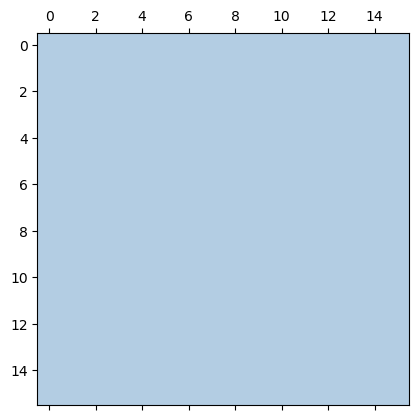

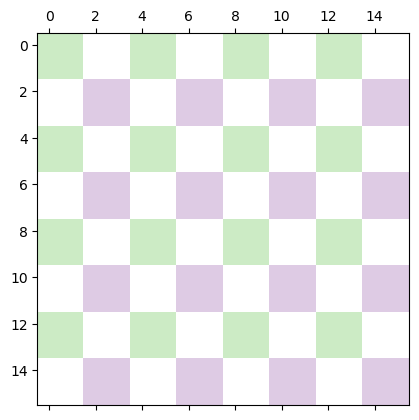

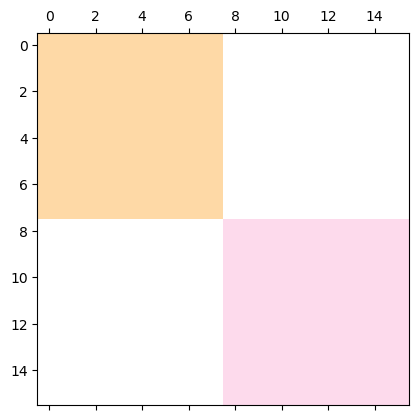

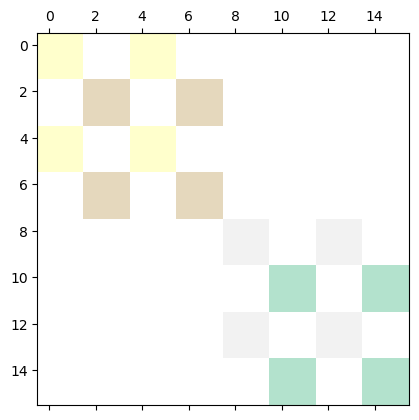

In [36]:
import torch

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import cm

def window_partition(x, window_size):
    # windows: (num_windows*B, window_size, window_size, C)
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, 
               window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, 
                window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / ((H // window_size) * (W // window_size)))
    x = windows.view(B,
                     H // window_size,
                     W // window_size,
                     window_size,
                     window_size,
                     -1)
    x = x.permute(0, 1, 3, 2, 4, 5)\
         .reshape(B, H, W, -1)
    return x

def compute_mask(H, W, window_size, shift_size):
    # create a mask matrix highlighting invalid connections
    img_mask = torch.zeros((1, H, W, 1))
    h_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    w_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1
    mask_windows = window_partition(img_mask, window_size)
    mask_windows = mask_windows.view(-1, window_size * window_size)
    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
    attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0))\
                         .masked_fill(attn_mask == 0, float(0.0))
    return attn_mask

def compute_mask_for_visualization(H, W, window_size, shift_size):
    # create a mask matrix highlighting invalid connections
    img_mask = torch.zeros((1, H, W, 1))
    h_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    w_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1
    mask_windows = window_partition(img_mask, window_size)
    mask_windows = mask_windows.view(-1, window_size * window_size)
    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
    same_region = (attn_mask == 0)
    region_ids = mask_windows.unsqueeze(1).expand(-1, mask_windows.size(1), -1)
    attn_mask = torch.where(same_region, region_ids, -1) + 1

    return attn_mask

window_size = 4
shift_size = 2
H, W = 8, 8
attn_mask = compute_mask_for_visualization(H, W, window_size, shift_size)

colors = [
    "white", 
    "#b3cde3",  
    "#ccebc5",  
    "#decbe4",  
    "#fed9a6",  
    "#ffffcc",  
    "#e5d8bd",  
    "#fddaec",  
    "#f2f2f2",  
    "#b3e2cd"   
]
cmap = ListedColormap(colors)
plt.matshow(attn_mask[0].numpy(), cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.matshow(attn_mask[1].numpy(), cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.matshow(attn_mask[2].numpy(), cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.matshow(attn_mask[3].numpy(), cmap=cmap, vmin=0, vmax=len(colors)-1)

plt.show()

In [41]:
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads, proj_drop=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size 
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

        # Table of (2M-1)^2 relative biases for each head
        table_size = (2 * window_size - 1) ** 2
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros(table_size, num_heads)
        ) 

        # Precompute a (M^2, M^2) matrix of indices
        coords = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid(coords, coords))
        coords_flat = coords.reshape(2, -1) 
        relative_coords = coords_flat[:, :, None] - coords_flat[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += window_size - 1
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1
        # final index for each (i,j)
        self.register_buffer(
            "relative_position_index",
            relative_coords.sum(-1).view(-1)  # flatten
        )
        # -----------------------------------

        self.attn_drop = nn.Dropout(0.0)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x, mask=None):
        B_, N, C = x.shape  # N = M^2
        # compute Q, K, Vs
        qkv = (
            self.qkv(x)
            .reshape(B_, N, 3, self.num_heads, C // self.num_heads)
            .permute(2, 0, 3, 1, 4)
        )
        q, k, v = qkv[0], qkv[1], qkv[2]  # (B_, heads, N, C_head)
        # scaled dot-product
        attn = (q @ k.transpose(-2, -1)) * self.scale  # (B_, heads, N, N)

        # add relative position bias
        # fetch biases: (N*N, heads) → (heads, N, N)
        bias = self.relative_position_bias_table[self.relative_position_index]
        bias = bias.view(self.window_size**2, self.window_size**2, -1).permute(2, 0, 1)
        attn = attn + bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            B = B_ // nW # (B_*nW, heads, N, N) → (B, nW, heads, N, N)
            attn = attn.view(B, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj_drop(x)
        return self.proj(x)

In [21]:
class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads,
                 window_size=7, shift_size=0, mlp_ratio=4.0):
        super().__init__()
        H, W = input_resolution
        self.input_resolution = (H, W)
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.shift_size = shift_size
        self.window_size = window_size
        # precompute mask
        self.register_buffer("attn_mask",
            compute_mask(H, W, window_size, shift_size)
            if shift_size > 0 else None)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim*mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim*mlp_ratio), dim)
        )

    def forward(self, x):
        B, L, C = x.shape
        H, W = self.input_resolution
        x = x.view(B, H, W, C)
        # cyclic shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        # attention
        x_windows = window_partition(x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size**2, C)
        attn_windows = self.attn(self.norm1(x_windows), mask=self.attn_mask)
        x = window_reverse(attn_windows, self.window_size, H, W)
        # reverse shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))
        x = x.view(B, L, C)
        # residual + MLP
        x = x + self.norm1(x)
        x = x + self.norm2(self.mlp(self.norm2(x)))
        return x


In [ ]:
class BasicLayer(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads,
                 window_size, mlp_ratio, downsample=True):
        super().__init__()
        self.blocks = nn.ModuleList()
        for i in range(depth):
            shift = 0 if (i % 2 == 0) else window_size // 2
            self.blocks.append(
                SwinTransformerBlock(dim, input_resolution,
                                     num_heads, window_size,
                                     shift, mlp_ratio)
            )
        self.downsample = PatchMerging(input_resolution, dim) if downsample else None

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        x = self.downsample(x) if self.downsample else x
        return x

class SwinTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=4,
                 in_chans=3, embed_dim=96, depths=[2,2,6,2],
                 num_heads=[3,6,12,24], window_size=7, mlp_ratio=4.0,
                 num_classes=1000):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size,
                                          embed_dim, in_chans)
        resolutions = [(img_size//patch_size, img_size//patch_size)]
        for i in range(3):
            h, w = resolutions[-1]
            resolutions.append((h // 2, w // 2))
        self.layers = nn.ModuleList()
        dims = [embed_dim * (2**i) for i in range(4)]
        for i in range(4):
            self.layers.append(
                BasicLayer(dims[i], resolutions[i],
                           depths[i], num_heads[i],
                           window_size, mlp_ratio,
                           downsample=(i < 3))
            )
        self.norm = nn.LayerNorm(dims[-1])
        self.head = nn.Linear(dims[-1], num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        x = x.mean(1)  # global average pooling
        return self.head(x)

model = SwinTransformer(
    img_size=224, patch_size=4, in_chans=3,
    embed_dim=96,
    depths=[2,2,6,2],
    num_heads=[3,6,12,24],
    window_size=7,
    mlp_ratio=4.0,
    num_classes=1000
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

x = torch.randn(2, 3, 224, 224, device=device)
with torch.no_grad():
    logits = model(x)

print("logits output: ", logits.shape)   # Should be [2, 1000]
probs = torch.softmax(logits, dim=-1)
print("probs: ", probs[:, :5]) 

logits output:  torch.Size([2, 1000])
probs： tensor([[0.0004, 0.0003, 0.0009, 0.0010, 0.0008],
        [0.0004, 0.0003, 0.0008, 0.0010, 0.0006]], device='cuda:0')
